# Notebook 05: Baseline-Läufe und Methodenvergleich

**Forschungsarbeit:** Evolutionäre Hyperparameter-Optimierung für RAG-Pipelines

Dieses Notebook wertet die abgeschlossenen Läufe von GA, Random Search, Grid Search und Default-Konfiguration aus:

1. Läufe einsammeln
2. Historien einlesen
3. Globales Optimum bestimmen
4. Ergebnistabelle je Lauf
5. Aggregation über die Seeds
6. Abbildung Methodenvergleich
7. Abbildung Endergebnis je Methode
8. Abbildung Suchgeschwindigkeit
9. Nachbewertung auf dem Test-Split
10. Beste Konfiguration je Lauf
11. Robustheit der Fitness-Gewichte

## Setup

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from src.environment import Environment
from src.evaluation.loader import load_qa_split
from src.experiment_runner.runner import ExperimentRunner
from src.rag_pipeline.pipeline import load_corpus

env = Environment()
env.make_dirs(env.figures_dir, env.tables_dir)

CONFIG_PATH = env.config_path
LOGS = env.logs_dir
FIGURES = env.figures_dir
TABLES = env.tables_dir

config = env.config
EXPERIMENT_NAME = env.experiment_name
METHODS = ("ga", "random", "grid", "default")
METHOD_COLORS = {"ga": "#1f77b4", "random": "#ff7f0e", "grid": "#2ca02c", "default": "#6e6e6e"}

plt.style.use("seaborn-v0_8-whitegrid")

print(env.summary())

experiment_name: ga_rag_optimizer_v1
seed: 42
raw_dir: data\raw
processed_dir: data\processed
corpus_dir: data\corpus
qa_split_path: data\processed\qa_pairs_split.json
corpus_meta_path: data\processed\corpus_meta.json
chroma_dir: data\processed\chroma_db
results_dir: results
logs_dir: results\logs
figures_dir: results\figures
tables_dir: results\tables


## Schritt 1: Läufe einsammeln

Pro Methode werden alle Run-Ordner unter `results/logs/{experiment_name}/{method}/` eingelesen, damit die Seed-Läufe von GA und Random Search ausgewertet werden.

In [2]:
run_dirs: dict[str, list[Path]] = {}
for method in METHODS:
    method_dir = LOGS / EXPERIMENT_NAME / method
    candidates = sorted(method_dir.glob("*_seed*"))
    if not candidates:
        raise FileNotFoundError(f"Keine Läufe für Methode '{method}' unter {method_dir}.")
    run_dirs[method] = candidates

    print(f"{method}:")
    for run_dir in candidates:
        print(f"    {run_dir.name}")

ga:
    2026-08-15T13-30-27_seed42
    2026-08-15T14-47-17_seed43
    2026-08-15T15-29-40_seed44
random:
    2026-08-15T10-39-57_seed42
    2026-08-15T11-40-01_seed43
    2026-08-15T12-36-09_seed44
grid:
    2026-08-15T09-51-19_seed42
default:
    2026-08-15T09-50-37_seed42


## Schritt 2: Historien einlesen

Je Lauf wird `{method}_history.jsonl` gelesen und um `method` und `seed` aus der `result.json` ergänzt. Alle Läufe landen in einem DataFrame.

In [3]:
history_frames = []
for method in METHODS:
    for run_dir in run_dirs[method]:
        result = json.loads((run_dir / "result.json").read_text(encoding="utf-8"))
        frame = pd.read_json(run_dir / f"{method}_history.jsonl", lines=True)
        frame = frame.drop(columns=["per_question"])
        frame["method"] = result["method"]
        frame["seed"] = result["seed"]
        history_frames.append(frame)

history = pd.concat(history_frames, ignore_index=True)
print(f"Läufe gesamt: {len(history_frames)}, Zeilen gesamt: {len(history)}")
history.head()

Läufe gesamt: 8, Zeilen gesamt: 3796


,eval_index,generation,individual,runtime_s,timestamp,composite,context_recall,context_precision,answer_f1,exact_match,method,seed
0,0,0.0,"{'chunk_size': 128, 'chunk_overlap': 0, 'top_k...",3.574901,2026-08-15 13:30:32,0.541579,0.680,0.362000,0.536595,0.45,ga,42
1,1,0.0,"{'chunk_size': 256, 'chunk_overlap': 0, 'top_k...",2.798994,2026-08-15 13:30:35,0.476507,0.455,0.485000,0.496690,0.41,ga,42
2,2,0.0,"{'chunk_size': 128, 'chunk_overlap': 0, 'top_k...",2.581550,2026-08-15 13:30:37,0.527479,0.545,0.620000,0.411595,0.32,ga,42
3,3,0.0,"{'chunk_size': 128, 'chunk_overlap': 32, 'top_...",4.080654,2026-08-15 13:30:41,0.537614,0.715,0.207000,0.631714,0.53,ga,42
4,4,0.0,"{'chunk_size': 512, 'chunk_overlap': 0, 'top_k...",1.291413,2026-08-15 13:30:42,0.520386,0.530,0.366667,0.661286,0.57,ga,42


## Schritt 3: Globales Optimum aus dem Grid-Lauf

 Globale Optimum aus Grid Search entnehmen, der beste Wert dient als Referenzlinie.

In [4]:
grid_history = history[history["method"] == "grid"]
GLOBAL_OPTIMUM = grid_history["composite"].max()

print(f"Globales Optimum: {GLOBAL_OPTIMUM:.3f} aus {len(grid_history)} Grid-Evaluationen")

Globales Optimum: 0.763 aus 540 Grid-Evaluationen


## Schritt 4: Ergebnistabelle je Lauf

Eine Tabelle mit dem besten Ergebnis, der Evaluation, bei der es erstmals erreicht wurde, der Gesamtzahl der Evaluationen, der Laufzeit in Sekunden und dem Abstand zum globalen Optimum.

In [5]:
rows = []
for run_key, run in history.groupby(["method", "seed"]):
    method, seed = run_key
    best = run.loc[run["composite"].idxmax()]
    rows.append(
        {
            "method": method,
            "seed": seed,
            "best_composite": best["composite"],
            "evals_to_best": int(best["eval_index"]) + 1,
            "n_evaluations": len(run),
            "runtime_s": run["runtime_s"].sum(),
        }
    )

summary = pd.DataFrame(rows).sort_values(["method", "seed"]).reset_index(drop=True)
summary["distance_to_optimum"] = GLOBAL_OPTIMUM - summary["best_composite"]

print(summary.round(3).to_string(index=False))
summary.to_csv(TABLES / "method_comparison.csv", index=False)

 method  seed  best_composite  evals_to_best  n_evaluations  runtime_s  distance_to_optimum
default    42           0.601              1              1      3.657                0.161
     ga    42           0.741            181            496   4582.191                0.021
     ga    43           0.763             50            483   2521.684                0.000
     ga    44           0.763            231            476   3246.342                0.000
   grid    42           0.763            400            540   2886.318                0.000
 random    42           0.759            274            600   3517.126                0.003
 random    43           0.763            161            600   3323.512                0.000
 random    44           0.762            379            600   3227.276                0.001


## Schritt 5: Aggregation über die Seeds

Mittelwert und Standardabweichung pro Methode über die Läufe sowie die Metrikkomponenten (Grid Search und Default laufen deterministisch und nur einmal).

In [6]:
COMPONENT_COLUMNS = ["context_recall", "context_precision", "answer_f1", "exact_match"]

best_index = history.groupby(["method", "seed"])["composite"].idxmax()
best_rows = history.loc[best_index]
components = best_rows.groupby("method")[COMPONENT_COLUMNS].mean()

aggregated = summary.groupby("method").agg(
    n_runs=("seed", "count"),
    best_composite_mean=("best_composite", "mean"),
    best_composite_std=("best_composite", "std"),
    n_evaluations_mean=("n_evaluations", "mean"),
    runtime_s_mean=("runtime_s", "mean"),
)
aggregated = aggregated.join(components).round(3).reset_index()

print(aggregated.to_string(index=False))
aggregated.to_csv(TABLES / "method_summary.csv", index=False)

 method  n_runs  best_composite_mean  best_composite_std  n_evaluations_mean  runtime_s_mean  context_recall  context_precision  answer_f1  exact_match
default       1                0.601                 NaN                 1.0           3.657           0.710              0.363      0.695        0.630
     ga       3                0.755               0.012               485.0        3450.072           0.812              0.644      0.792        0.747
   grid       1                0.763                 NaN               540.0        2886.318           0.765              0.765      0.757        0.700
 random       3                0.761               0.002               600.0        3355.972           0.763              0.763      0.756        0.700


## Schritt 6: Abbildung Methodenvergleich

Je Methode eine Kurve aus dem Mittelwert der Best-so-far-Werte über die Seeds. 

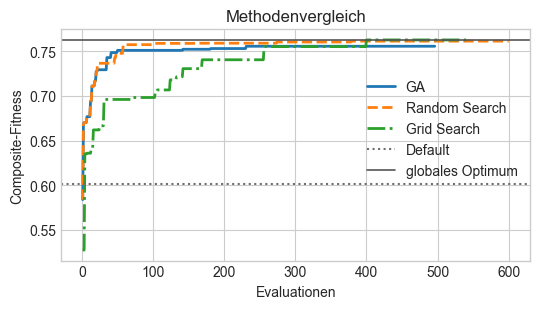

In [7]:
CURVES = [
    ("ga", "GA", METHOD_COLORS["ga"], "-"),
    ("random", "Random Search", METHOD_COLORS["random"], "--"),
    ("grid", "Grid Search", METHOD_COLORS["grid"], "-."),
]

fig, ax = plt.subplots(figsize=(5.5, 3.2))
for method, label, color, style in CURVES:
    best_so_far = {}
    for seed, group in history[history["method"] == method].groupby("seed"):
        ordered = group.sort_values("eval_index")
        best_so_far[seed] = ordered["composite"].cummax().reset_index(drop=True)

    runs = pd.DataFrame(best_so_far).ffill()
    evaluations = runs.index + 1
    ax.plot(evaluations, runs.mean(axis=1), color=color, linestyle=style, linewidth=2, label=label)

default_best = history.loc[history["method"] == "default", "composite"].max()
ax.axhline(
    default_best, color=METHOD_COLORS["default"], linestyle=":", linewidth=1.5, label="Default"
)
ax.axhline(GLOBAL_OPTIMUM, color="#555555", linewidth=1.2, label="globales Optimum")

ax.set_xlabel("Evaluationen")
ax.set_ylabel("Composite-Fitness")
ax.set_title("Methodenvergleich")
ax.legend(loc="center right", bbox_to_anchor=(1.0, 0.57), framealpha=0.9)
fig.tight_layout()
fig.savefig(FIGURES / "06_methodenvergleich_aggregiert.png", dpi=300)
plt.show()

## Schritt 7: Abbildung Endergebnis je Methode

Ein Balken je Methode mit der mittleren besten Composite-Fitness sowie die Referenzlinie des globalen Optimums. Bei GA und Random Search zeigt ein Fehlerbalken die Standardabweichung über die drei Seeds, Grid Search und Default laufen deterministisch und haben keine Streuung.

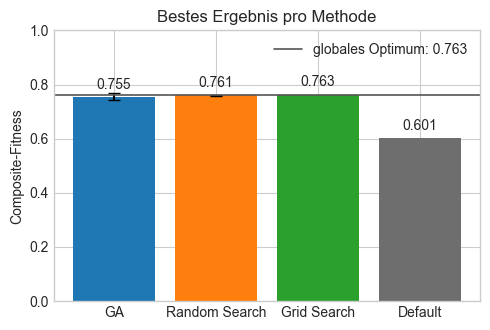

In [8]:
BAR_LABELS = ["GA", "Random Search", "Grid Search", "Default"]

bars = aggregated.set_index("method").reindex(METHODS)
errors = bars["best_composite_std"]
optimum_label = f"globales Optimum: {GLOBAL_OPTIMUM:.3f}"

fig, ax = plt.subplots(figsize=(5, 3.4))
bar_colors = [METHOD_COLORS[method] for method in METHODS]
ax.bar(BAR_LABELS, bars["best_composite_mean"], yerr=errors, capsize=4, color=bar_colors)

for position in range(len(METHODS)):
    value = bars["best_composite_mean"].iloc[position]
    ax.text(position, value + 0.03, f"{value:.3f}", ha="center")

ax.axhline(GLOBAL_OPTIMUM, color="#555555", linewidth=1.2, label=optimum_label)
ax.legend(loc="upper right", framealpha=0.9)
ax.set_ylim(0.0, 1.0)
ax.set_ylabel("Composite-Fitness")
ax.set_title("Bestes Ergebnis pro Methode")
fig.tight_layout()
fig.savefig(FIGURES / "06_endergebnis_je_methode.png", dpi=300)
plt.show()

## Schritt 8: Abbildung Suchgeschwindigkeit

Die Suchgeschwindigkeit abgebildet bis zum Bestwert. Grid Search steht ohne Seed in der Beschriftung, weil die Aufzählung des Rasters deterministisch ist und der Seed dort keine Wirkung hat.

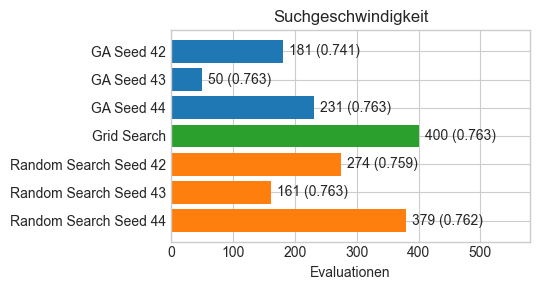

In [9]:
NAMES = {"ga": "GA", "random": "Random Search", "grid": "Grid Search"}

speed = summary[summary["method"] != "default"]
labels = [
    NAMES[run.method] if run.method == "grid" else f"{NAMES[run.method]} Seed {run.seed}"
    for run in speed.itertuples()
]

fig, ax = plt.subplots(figsize=(5.5, 3))
bar_colors = [METHOD_COLORS[method] for method in speed["method"]]
ax.barh(labels, speed["evals_to_best"], color=bar_colors)
ax.invert_yaxis()

for position, run in enumerate(speed.itertuples()):
    text = f"{run.evals_to_best} ({run.best_composite:.3f})"
    ax.text(run.evals_to_best + 10, position, text, va="center")

ax.set_xlim(0, speed["evals_to_best"].max() * 1.45)
ax.set_xlabel("Evaluationen")
ax.set_title("Suchgeschwindigkeit")
fig.tight_layout()
fig.savefig(FIGURES / "06_evaluationen_bis_bestwert.png", dpi=300)
plt.show()

## Schritt 9: Nachbewertung auf dem Test-Split

Der Durchlauf lief auf insgesamt 100 Train-Fragen. Die 50 Test-Fragen sollen zeigen, ob die gefundene Konfiguration auf ungesehenen Fragen hält.

In [10]:
FORCE_TEST_EVAL = False
test_eval_path = TABLES / "test_split_evaluation.csv"

if test_eval_path.exists() and not FORCE_TEST_EVAL:
    test_eval = pd.read_csv(test_eval_path)
else:
    documents = load_corpus(env.corpus_dir)
    qa_test = load_qa_split(env.qa_split_path)["test"]
    fitness_fn = ExperimentRunner(CONFIG_PATH).build_fitness_fn(documents, qa_test)
    print(f"Nachbewertung auf {len(qa_test)} Test-Fragen, {len(documents)} Dokumente.")

    test_rows = []
    for method in METHODS:
        for run_dir in run_dirs[method]:
            result = json.loads((run_dir / "result.json").read_text(encoding="utf-8"))
            fitness = fitness_fn(result["best_individual"])
            test_rows.append(
                {
                    "method": result["method"],
                    "seed": result["seed"],
                    "train_composite": result["best_fitness"],
                    "test_composite": fitness["composite"],
                    "test_context_recall": fitness["context_recall"],
                    "test_context_precision": fitness["context_precision"],
                    "test_answer_f1": fitness["answer_f1"],
                    "test_exact_match": fitness["exact_match"],
                }
            )

    test_eval = pd.DataFrame(test_rows)
    test_eval.to_csv(test_eval_path, index=False)

test_eval["gap"] = test_eval["train_composite"] - test_eval["test_composite"]
print(test_eval.round(3).to_string(index=False))

 method  seed  train_composite  test_composite  test_context_recall  test_context_precision  test_answer_f1  test_exact_match   gap
     ga    42            0.741           0.685                 0.87                   0.388           0.737              0.72 0.056
     ga    43            0.763           0.759                 0.79                   0.790           0.687              0.66 0.004
     ga    44            0.763           0.759                 0.79                   0.790           0.687              0.66 0.004
 random    42            0.759           0.759                 0.79                   0.790           0.687              0.66 0.000
 random    43            0.763           0.759                 0.79                   0.790           0.687              0.66 0.004
 random    44            0.762           0.759                 0.79                   0.790           0.687              0.66 0.003
   grid    42            0.763           0.759                 0.79         

## Schritt 10: Beste Konfiguration je Lauf

Die Hyperparameter des besten Individuums jedes Laufs als Tabelle.

In [11]:
best_index = history.groupby(["method", "seed"])["composite"].idxmax()
best_rows = history.loc[best_index].reset_index(drop=True)

best_configs = pd.DataFrame(list(best_rows["individual"]))
best_configs.insert(0, "method", best_rows["method"])
best_configs.insert(1, "seed", best_rows["seed"])
best_configs["best_composite"] = best_rows["composite"].round(3)

print(best_configs.to_string(index=False))
best_configs.to_csv(TABLES / "best_configurations.csv", index=False)

 method  seed  chunk_size  chunk_overlap  top_k        embedding_model retrieval_strategy  best_composite
default    42        1000            200      4       all-MiniLM-L6-v2              dense           0.601
     ga    42         512            128      5  BAAI/bge-base-en-v1.5              dense           0.741
     ga    43        1024              0      2 BAAI/bge-small-en-v1.5              dense           0.763
     ga    44        1024              0      2 BAAI/bge-small-en-v1.5              dense           0.763
   grid    42        1024              0      2 BAAI/bge-small-en-v1.5              dense           0.763
 random    42        1024             64      2 BAAI/bge-small-en-v1.5              dense           0.759
 random    43        1024              0      2 BAAI/bge-small-en-v1.5              dense           0.763
 random    44        1024            128      2 BAAI/bge-small-en-v1.5              dense           0.762


## Schritt 11: Robustheit der Fitness-Gewichte

Robustheitsanalyse der Gewichtung, weil der Grid-Lauf den vollständigen gültigen Suchraum bewertet hat, lässt sich für beliebige Gewichte exakt bestimmen, welche Konfiguration vorn läge. Die Composite-Werte werden dafür aus den geloggten Einzelmetriken der 540 Grid-Evaluationen neu gewichtet, es läuft kein neues Experiment. Geprüft werden fünf benannte Szenarien und ein 0,1-Raster über alle Gewichtskombinationen auf dem Simplex (66 Punkte). Die Spalte `same_as_standard` zeigt, ob das Optimum der Standardgewichtung (0,4/0,3/0,3) vorn bleibt.

In [12]:
grid_rows = history[history["method"] == "grid"].reset_index(drop=True)
standard_best = grid_rows.loc[grid_rows["composite"].idxmax(), "individual"]


def best_for(w_recall, w_precision, w_f1):
    """Returns the winning grid configuration under the given weights and its score."""
    weighted = (
        w_recall * grid_rows["context_recall"]
        + w_precision * grid_rows["context_precision"]
        + w_f1 * grid_rows["answer_f1"]
    )
    return grid_rows.loc[weighted.idxmax(), "individual"], weighted.max()


scenarios = [
    ("standard", 0.4, 0.3, 0.3),
    ("gleichgewichtet", 1 / 3, 1 / 3, 1 / 3),
    ("recall-lastig", 0.5, 0.25, 0.25),
    ("precision-lastig", 0.25, 0.5, 0.25),
    ("f1-lastig", 0.25, 0.25, 0.5),
]
for recall_step in range(11):
    for precision_step in range(11 - recall_step):
        f1_step = 10 - recall_step - precision_step
        name = f"raster_{recall_step}_{precision_step}_{f1_step}"
        scenarios.append((name, recall_step / 10, precision_step / 10, f1_step / 10))

rows = []
for name, w_recall, w_precision, w_f1 in scenarios:
    config, score = best_for(w_recall, w_precision, w_f1)
    row = {"scenario": name, "w_recall": w_recall, "w_precision": w_precision, "w_f1": w_f1}
    row.update(config)
    row["weighted_composite"] = score
    row["same_as_standard"] = config == standard_best
    rows.append(row)

robustness = pd.DataFrame(rows)
robustness.to_csv(TABLES / "weight_robustness.csv", index=False)

raster = robustness[robustness["scenario"].str.startswith("raster")]
same_count = raster["same_as_standard"].sum()
print(f"Standard-Optimum bleibt in {same_count} von {len(raster)} Rasterpunkten vorn.")
print()
print(robustness[~robustness["scenario"].str.startswith("raster")].round(3).to_string(index=False))

Standard-Optimum bleibt in 23 von 66 Rasterpunkten vorn.

        scenario  w_recall  w_precision  w_f1  chunk_size  chunk_overlap  top_k        embedding_model retrieval_strategy  weighted_composite  same_as_standard
        standard     0.400        0.300 0.300        1024              0      2 BAAI/bge-small-en-v1.5              dense               0.763              True
 gleichgewichtet     0.333        0.333 0.333        1024              0      2 BAAI/bge-small-en-v1.5              dense               0.762              True
   recall-lastig     0.500        0.250 0.250         256             32     10  BAAI/bge-base-en-v1.5              dense               0.776             False
precision-lastig     0.250        0.500 0.250        1024              0      2 BAAI/bge-small-en-v1.5              dense               0.763              True
       f1-lastig     0.250        0.250 0.500        1024              0      3 BAAI/bge-small-en-v1.5              dense               0.765 